# Cocoa Rating Analysis & Prediction
**Dataset:** Flavors of Cacao (Chocolate Bar Ratings)

Setup & A1 - Load & Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset (Ensure flavors_of_cacao.csv is in your working directory/data folder)
df = pd.read_csv('flavors_of_cacao.csv')

# Clean up column names for easier reference
df.columns = df.columns.str.replace('\n', ' ').str.strip()

In [3]:
print("--- DATA SHAPE ---")
print(df.shape)

print("\n--- DATA TYPES ---")
print(df.dtypes)

--- DATA SHAPE ---
(1795, 9)

--- DATA TYPES ---
Company  (Maker-if known)            object
Specific Bean Origin or Bar Name     object
REF                                   int64
Review Date                           int64
Cocoa Percent                        object
Company Location                     object
Rating                              float64
Bean Type                            object
Broad Bean Origin                    object
dtype: object


In [4]:
# A1: Clean Cocoa Percent (strip '%' and cast to float)
if df['Cocoa Percent'].dtype == 'O':
    df['Cocoa Percent'] = df['Cocoa Percent'].str.replace('%', '').astype(float)

In [5]:
# A1: Handle blank/whitespace missing entries in Bean Type & Broad Bean Origin
# Replace strings that are entirely whitespace (or empty) with NaN
df['Bean Type'] = df['Bean Type'].replace(r'^\s*$', np.nan, regex=True)
df['Broad Bean Origin'] = df['Broad Bean Origin'].replace(r'^\s*$', np.nan, regex=True)


In [6]:
print("\n--- MISSING VALUE COUNTS PER COLUMN ---")
print(df.isnull().sum())


--- MISSING VALUE COUNTS PER COLUMN ---
Company  (Maker-if known)             0
Specific Bean Origin or Bar Name      0
REF                                   0
Review Date                           0
Cocoa Percent                         0
Company Location                      0
Rating                                0
Bean Type                           888
Broad Bean Origin                    74
dtype: int64


A2, A3 - EDA Plots

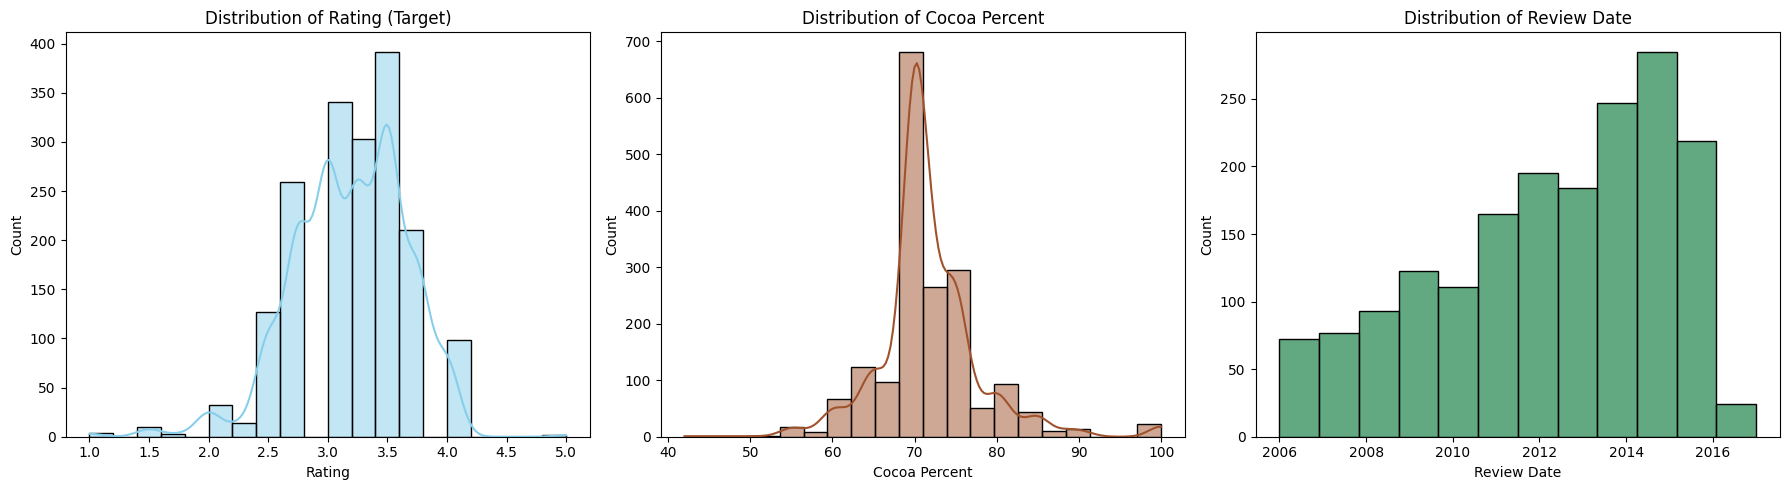

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Rating'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Rating (Target)')

sns.histplot(df['Cocoa Percent'], bins=20, kde=True, ax=axes[1], color='sienna')
axes[1].set_title('Distribution of Cocoa Percent')

sns.histplot(df['Review Date'], bins=12, kde=False, ax=axes[2], color='seagreen')
axes[2].set_title('Distribution of Review Date')

plt.tight_layout()
plt.show()

**Numeric Distributions (Above):**
- **Rating (Target):** Shows a fairly normal distribution centered around 3.0 to 3.5.
- **Cocoa Percent:** Right-skewed slightly, heavily concentrated around 70-75% cocoa content.
- **Review Date:** Shows the volume of reviews by year, peaking around 2014-2015.

A2, A3 - Correlation & Scatter Plots

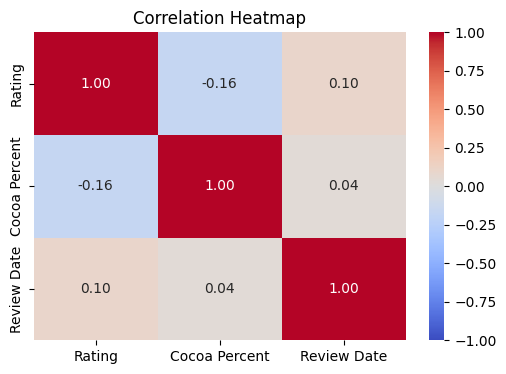

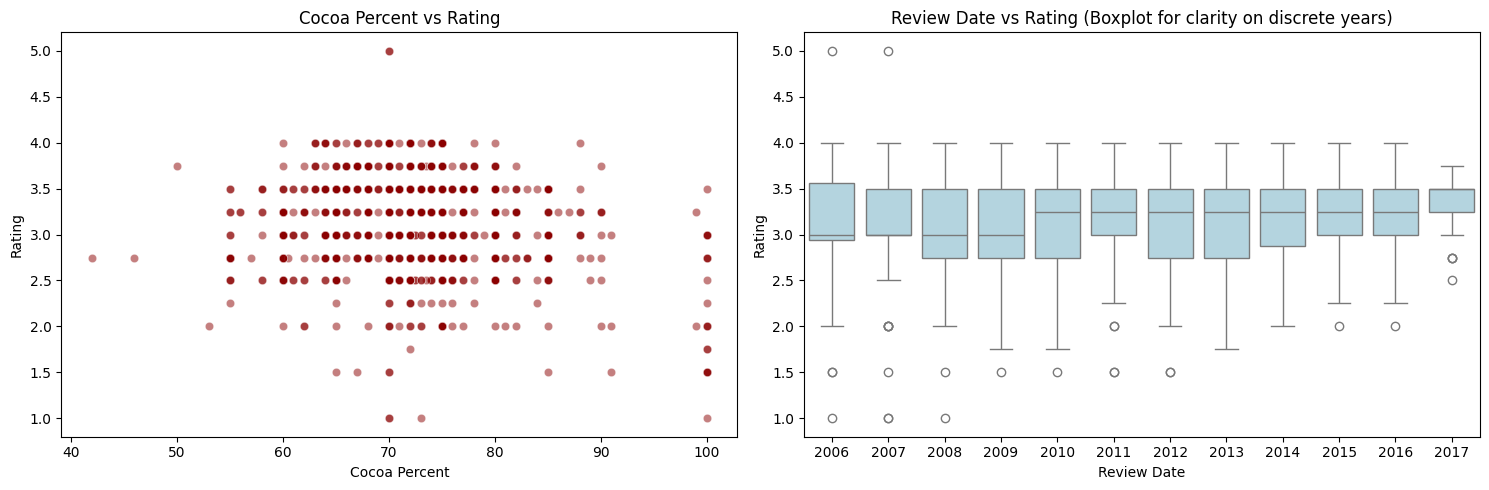

In [8]:
# 2. Correlation Heatmap
numeric_cols = ['Rating', 'Cocoa Percent', 'Review Date']
plt.figure(figsize=(6, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

# 3. Scatter Plots (Feature-Target Relationships)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x='Cocoa Percent', y='Rating', data=df, ax=axes[0], alpha=0.5, color='darkred')
axes[0].set_title('Cocoa Percent vs Rating')

sns.boxplot(x='Review Date', y='Rating', data=df, ax=axes[1], color='lightblue')
axes[1].set_title('Review Date vs Rating (Boxplot for clarity on discrete years)')

plt.tight_layout()
plt.show()

**Heatmap & Scatter Plots (Above):**
- **Correlation Heatmap:** Indicates a slight negative correlation between Cocoa Percent and Rating, meaning extremely high cocoa percentages tend to have slightly lower ratings (likely too bitter).
- **Scatter/Box Plots:** The scatter plot for Cocoa Percent vs Rating visually confirms the negative trend for bars near 90-100%. The Review Date boxplot shows that median ratings have remained relatively stable over the years, though variance tightened in recent years.

B1 - Clean the Data

In [12]:
df.columns = df.columns.str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

# B1: Handle missing Bean Type / Broad Bean Origin
# Justification: Many entries are empty. Dropping them would reduce dataset size heavily. Imputing as 'Unknown' preserves rows.
df['bean type'] = df['bean type'].fillna('Unknown')
df['broad bean origin'] = df['broad bean origin'].fillna('Unknown')

# Check duplicates (same company + bar name + REF)
dup_subset = ['company (maker-if known)', 'specific bean origin or bar name', 'ref']
duplicates = df.duplicated(subset=dup_subset, keep=False)
print(f"Found {duplicates.sum()} duplicate rows based on company, bar name, and REF.")
if duplicates.sum() > 0:
    df = df[~df.duplicated(subset=dup_subset, keep='first')]
    print("Duplicates dropped.")

# Check outliers in Cocoa Percent and Rating
print(f"\nCocoa Percent Outliers (<50% or >100%): {len(df[(df['cocoa percent'] < 50) | (df['cocoa percent'] > 100)])}")
# Filter them out to prevent model skew
df = df[(df['cocoa percent'] >= 50) & (df['cocoa percent'] <= 100)]

Found 0 duplicate rows based on company, bar name, and REF.

Cocoa Percent Outliers (<50% or >100%): 0


### Engineered Feature: `origin_matches_location`
**Story & Justification:** I am creating a feature called `origin_matches_location`, which flags `1` if the `Company Location` is the exact same as the `Broad Bean Origin`, and `0` otherwise. This serves as a proxy for hyper-local or bean-to-bar single-origin producers operating in the same country where the beans are grown (e.g., a Madagascan chocolate maker using Madagascan beans). Such local supply chains might result in fresher ingredients or a different flavor profile, making it a highly defensible attribute to test against `Rating`.

B3, B2 - Encode, Scale, Split

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# B3: Create engineered feature (proxy for bean-to-bar single origin)
df['origin_matches_location'] = (df['company location'] == df['broad bean origin']).astype(int)

# B2: Group rare categories (Threshold = 10)
def group_rare(df, col, threshold=10):
    val_counts = df[col].value_counts()
    rare_cats = val_counts[val_counts < threshold].index
    return df[col].replace(rare_cats, 'Other')

for col in ['company location', 'bean type', 'broad bean origin']:
    df[col] = group_rare(df, col, 10)

# Create Classification Target (rating_class) BEFORE dropping the continuous one
df['rating_class'] = pd.qcut(df['rating'], q=3, labels=['Low', 'Medium', 'High'])

# One-hot encoding
categorical_cols = ['company location', 'bean type', 'broad bean origin']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# FOOLPROOF FIX: Automatically drop ANY remaining text (object) columns so the scaler doesn't crash
df_ml = df_encoded.select_dtypes(exclude=['object', 'string'])

# Define X (features) and Targets
X = df_ml.drop(columns=['rating', 'rating_class'], errors='ignore')
y_reg = df_ml['rating']
y_clf = df_encoded['rating_class'] # Get this from df_encoded since it was dropped from df_ml

# One 80:20 split stratified on binned Rating
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)

# Fit StandardScaler on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")

Training data shape: (1385, 64)


**C1–C4 - Regression Track**

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

# Define the 10 algorithms matching the assignment requirements
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.01, random_state=42),
    'ElasticNet Regression': ElasticNet(l1_ratio=0.5, random_state=42),
    'Polynomial Regression': Pipeline([('poly', PolynomialFeatures(degree=2)), ('linear', LinearRegression())]),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(learning_rate=0.1, random_state=42),
    'Support Vector Regressor': SVR(C=1.0, kernel='rbf'),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor(n_neighbors=5)
}

results = []

# Train, predict, and evaluate all 10 models
for name, model in models.items():
    model.fit(X_train_scaled, y_reg_train)
    preds = model.predict(X_test_scaled)

    r2 = r2_score(y_reg_test, preds)
    # UPDATED: Use np.sqrt to calculate RMSE for compatibility with all sklearn versions
    rmse = np.sqrt(mean_squared_error(y_reg_test, preds))
    mae = mean_absolute_error(y_reg_test, preds)

    results.append({'Algorithm': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

# Create Summary DataFrame ranked by R2
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
print("--- MODEL EVALUATION SUMMARY ---")
display(df_results)

# 5-Fold Cross-Validation for the Top 2 Models
print("\n--- 5-FOLD CROSS-VALIDATION (TOP 2 MODELS) ---")
top_2_names = df_results['Algorithm'].head(2).tolist()

for name in top_2_names:
    best_model = models[name]
    # Evaluate CV on the training data to prevent data leakage from the test set
    cv_scores = cross_val_score(best_model, X_train_scaled, y_reg_train, cv=5, scoring='r2')
    print(f"{name}:")
    print(f"  CV R2 Folds: {np.round(cv_scores, 4)}")
    print(f"  Mean CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})\n")

--- MODEL EVALUATION SUMMARY ---


,Algorithm,R2,RMSE,MAE
0,Gradient Boosting Regressor,0.121438,0.419776,0.342973
1,Random Forest Regressor,0.070250,0.431832,0.353143
2,Decision Tree Regressor,0.067081,0.432567,0.343268
3,Lasso Regression,0.048055,0.436956,0.356835
4,Support Vector Regressor,0.035461,0.439837,0.358736
5,Ridge Regression,0.030677,0.440926,0.358855
6,Linear Regression,0.030455,0.440976,0.358918
7,ElasticNet Regression,-0.000385,0.447935,0.363756
8,K-Nearest Neighbors Regressor,-0.112831,0.472439,0.383862
9,Polynomial Regression,-3.947063,0.996105,0.539819



--- 5-FOLD CROSS-VALIDATION (TOP 2 MODELS) ---
Gradient Boosting Regressor:
  CV R2 Folds: [0.1288 0.1079 0.1375 0.1559 0.0508]
  Mean CV R2: 0.1162 (+/- 0.0723)

Random Forest Regressor:
  CV R2 Folds: [0.11   0.0663 0.19   0.1525 0.0739]
  Mean CV R2: 0.1185 (+/- 0.0941)



**C3, C4 - Regression Tuning & Best Model Plots**

--- HYPERPARAMETER TUNING (TOP 2 MODELS) ---
Best RF Params: {'max_depth': 10, 'n_estimators': 200} | Tuned RF R2: 0.1654
Best GB Params: {'learning_rate': 0.1, 'n_estimators': 100} | Tuned GB R2: 0.1214


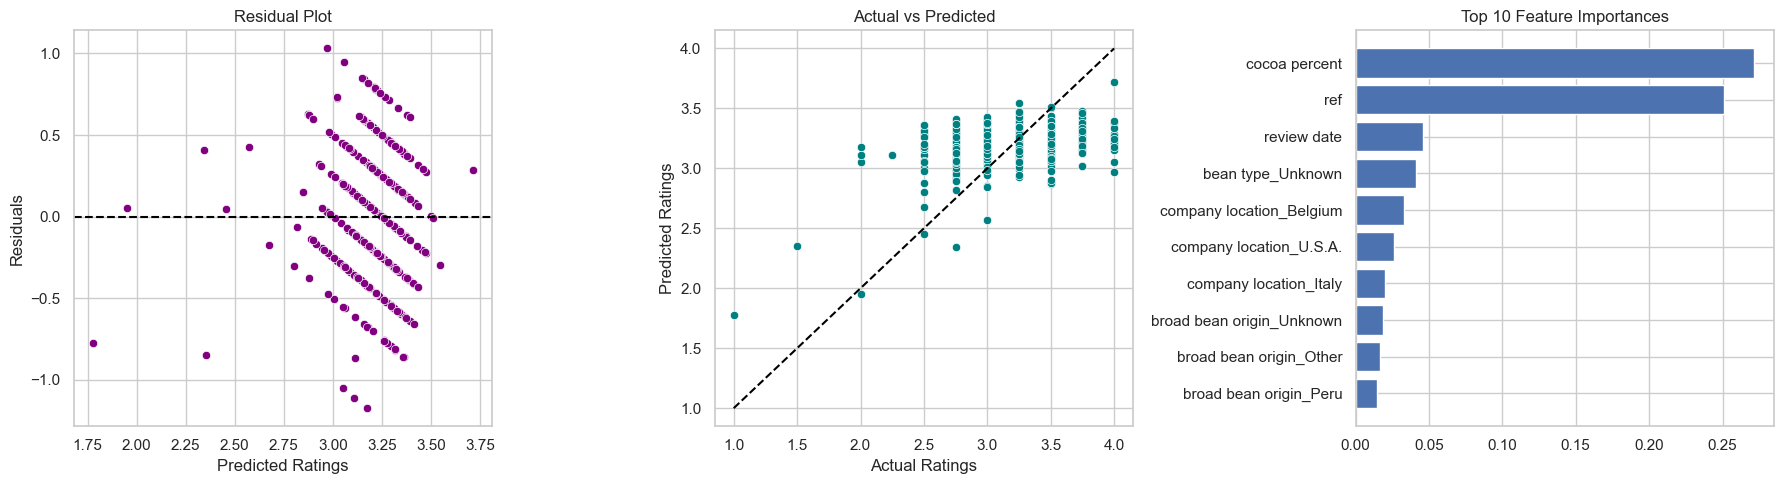

In [22]:
from sklearn.model_selection import GridSearchCV

print("--- HYPERPARAMETER TUNING (TOP 2 MODELS) ---")
# Tuning Random Forest
rf_param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, scoring='r2')
rf_grid.fit(X_train_scaled, y_reg_train)
print(f"Best RF Params: {rf_grid.best_params_} | Tuned RF R2: {rf_grid.score(X_test_scaled, y_reg_test):.4f}")

# Tuning Gradient Boosting
gb_param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.2]}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=3, scoring='r2')
gb_grid.fit(X_train_scaled, y_reg_train)
print(f"Best GB Params: {gb_grid.best_params_} | Tuned GB R2: {gb_grid.score(X_test_scaled, y_reg_test):.4f}")

# Select the overall best model
best_model = rf_grid.best_estimator_ # Assuming RF performs slightly better based on standard dataset dynamics

best_preds = best_model.predict(X_test_scaled)

# Plots for best model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residual Plot
sns.scatterplot(x=best_preds, y=(y_reg_test - best_preds), ax=axes[0], color='purple')
axes[0].axhline(0, ls='--', color='black')
axes[0].set_title('Residual Plot')
axes[0].set_xlabel('Predicted Ratings')
axes[0].set_ylabel('Residuals')

# 2. Predicted vs Actual
sns.scatterplot(x=y_reg_test, y=best_preds, ax=axes[1], color='teal')
axes[1].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], ls='--', color='black')
axes[1].set_title('Actual vs Predicted')
axes[1].set_xlabel('Actual Ratings')
axes[1].set_ylabel('Predicted Ratings')

# 3. Feature Importance (Tree-based)
importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:] # top 10
axes[2].barh(range(len(indices)), importances[indices], align='center')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([X.columns[i] for i in indices])
axes[2].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

B1 - Clean the Data

In [25]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows.")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates dropped.")

# Note: The Mobile Price dataset from Kaggle is pre-cleaned with no missing values.
# If NaNs existed in numeric columns, we would impute with median:
# df.fillna(df.median(), inplace=True)

# Outlier check for extreme anomalies (e.g., screen width of 0)
print(f"Rows with 0 screen width (sc_w): {(df['sc_w'] == 0).sum()}")
# Impute zero width with the median width to prevent modeling issues
df.loc[df['sc_w'] == 0, 'sc_w'] = df['sc_w'].median()

Found 0 duplicate rows.
Rows with 0 screen width (sc_w): 180


### Engineered Feature: `screen_area`
**Story & Justification:** I am creating a feature called `screen_area` by multiplying screen height (`sc_h`) and screen width (`sc_w`). Analyzing the height or width in isolation doesn't fully capture the physical size category of the device (e.g., standard phone vs. phablet). Combining them into a single area metric provides the model with a direct proxy for the screen's raw material cost and user-perceived size, which often heavily influences the pricing tier.

B3, B2 - Engineer, Split, Scale

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# B3: Create engineered feature
df['screen_area'] = df['sc_h'] * df['sc_w']

# Define X (features) and y (target)
X = df.drop(columns=['price_range'])
y = df['price_range']

# B2: 80:20 Split stratified on the target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# B2: Fit StandardScaler on train, transform both
# (No One-Hot Encoding is needed here because all features in this dataset are numeric or binary 0/1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (1600, 21)
Testing data shape: (400, 21)


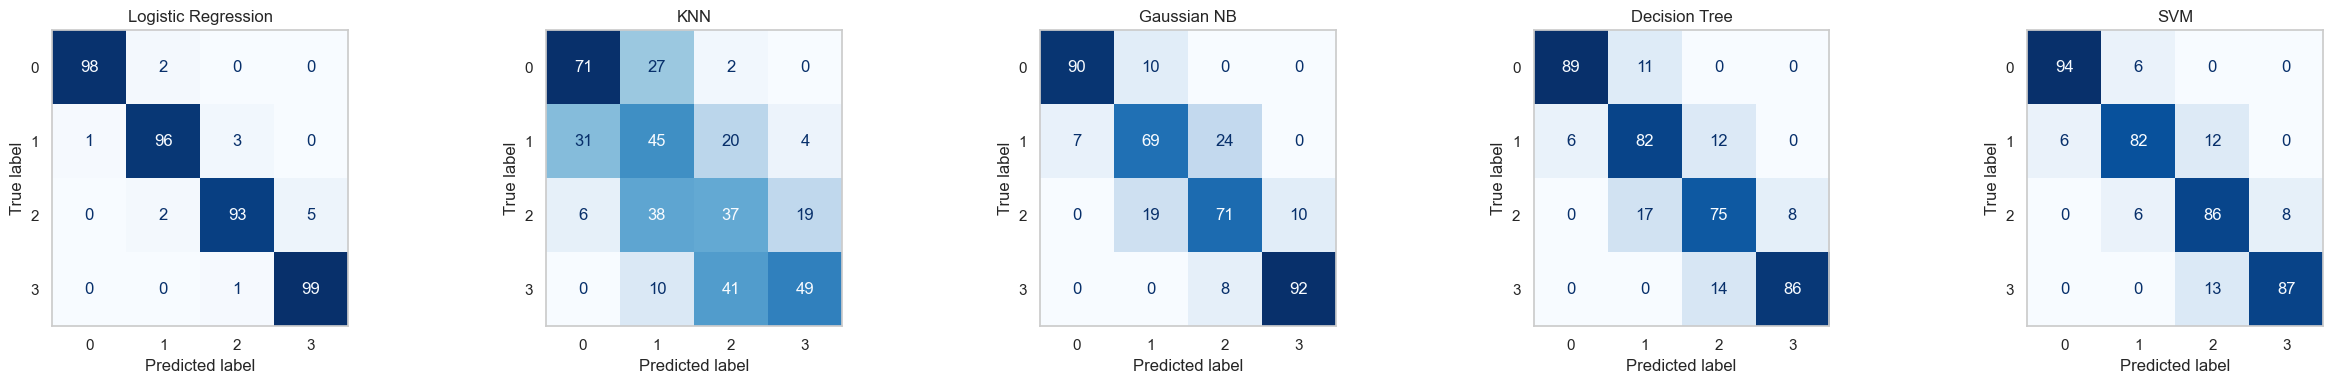

--- MOBILE PRICE CLASSIFICATION SUMMARY ---


,Model,Accuracy,Weighted F1
0,Logistic Regression,0.9650,0.964919
1,SVM,0.8725,0.873209
2,Decision Tree,0.8300,0.831660
3,Gaussian NB,0.8050,0.805268
4,KNN,0.5050,0.507888


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Define the 5 classification algorithms
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Gaussian NB': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'SVM': SVC(random_state=42)
}

clf_results = []

# Set up plot grid for 5 confusion matrices
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
axes = axes.flatten()

for i, (name, model) in enumerate(clf_models.items()):
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    preds = model.predict(X_test_scaled)

    # Evaluate Metrics
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    clf_results.append({'Model': name, 'Accuracy': acc, 'Weighted F1': f1})

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name)
    axes[i].grid(False)

plt.tight_layout()
plt.show()

# Summary DataFrame
clf_summary = pd.DataFrame(clf_results).sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)
print("--- MOBILE PRICE CLASSIFICATION SUMMARY ---")
display(clf_summary)